# Analyze a Distribution of an Existing Data
1. Score distribution per OSATS dimension
2. PRE and POST Split
3. Inter rater agreement
4. Spearman correlation between all pair of dimension
5. How SUTURES is associated to GRS

NOTE: GRS = Global Rating Score

## 1. Score Distribution per OSATS Dimension

In [48]:
import csv

evaluater_A = []
with open("/home/sov1/OpenSutureNet/data/osats_score.csv", "r") as f:
    data = csv.reader(f)
    next(data)
    for row in data:
        if row[4] == 'A':
            evaluater_A.append(row)

print(evaluater_A)
print(len(evaluater_A))

[['AHO729', 'E-LEARNING', 'PRE', '1', 'A', 'P54M', '2', '1', '2', '2', '1', '2', '2', '1', '13'], ['AHO729', 'E-LEARNING', 'POST', '4.5', 'A', 'M45P', '4', '4', '4', '3', '3', '4', '3', '3', '28'], ['AHU348', 'TUTOR-LED', 'PRE', '0.5', 'A', 'D44W', '1', '1', '1', '1', '1', '1', '1', '1', '8'], ['AHU348', 'TUTOR-LED', 'POST', '3', 'A', 'W44D', '1', '1', '2', '1', '1', '2', '2', '1', '11'], ['AJJ164', 'E-LEARNING', 'PRE', '2.5', 'A', 'V34K', '1', '1', '1', '1', '1', '2', '1', '1', '9'], ['AJJ164', 'E-LEARNING', 'POST', '6', 'A', 'K43V', '3', '2', '3', '3', '2', '3', '2', '3', '21'], ['ALN135', 'E-LEARNING', 'PRE', '0.5', 'A', 'V16A', '1', '1', '1', '1', '1', '1', '1', '1', '8'], ['ALN135', 'E-LEARNING', 'POST', '3.5', 'A', 'A61V', '4', '2', '3', '3', '2', '3', '3', '4', '24'], ['ASG463', 'HMD-BASED', 'PRE', '0.5', 'A', 'S84F', '1', '1', '1', '1', '1', '1', '1', '1', '8'], ['ASG463', 'HMD-BASED', 'POST', '3', 'A', 'F48S', '2', '3', '3', '3', '4', '5', '3', '4', '27'], ['AVY994', 'TUTOR-LE

In [ ]:
# OSATS index = 6, 7, 8, 9, 10, 11, 12, 13
OSATS_index = {
    6: "Respect",
    7: "Motion",
    8: "Instrument",
    9: "Suture",
    10: "Flow",
    11: "Knowledge",
    12: "Performance",
    13: "Final Quality"
}

In [29]:
# Create an array that will count all of the spread of data
# count_all = [[0, 0, 0, 0, 0]] * 8 -- this will create ference to the same list and everything is modified
count_all = [[0, 0, 0, 0, 0] for _ in range(0,8)]

for i in range(0, 8):
    for item in evaluater_A:
        if item[6 + i] == '1':
            count_all[i][0] += 1
        elif item[6 + i] == '2':
            count_all[i][1] += 1
        elif item[6 + i] == '3':
            count_all[i][2] += 1
        elif item[6 + i] == '4':
            count_all[i][3] += 1
        else:
            count_all[i][4] += 1
    print(count_all)

[[101, 40, 81, 86, 6], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0]]
[[101, 40, 81, 86, 6], [113, 64, 108, 28, 1], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0]]
[[101, 40, 81, 86, 6], [113, 64, 108, 28, 1], [93, 47, 89, 76, 9], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0]]
[[101, 40, 81, 86, 6], [113, 64, 108, 28, 1], [93, 47, 89, 76, 9], [108, 52, 91, 61, 2], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0]]
[[101, 40, 81, 86, 6], [113, 64, 108, 28, 1], [93, 47, 89, 76, 9], [108, 52, 91, 61, 2], [108, 50, 80, 73, 3], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0]]
[[101, 40, 81, 86, 6], [113, 64, 108, 28, 1], [93, 47, 89, 76, 9], [108, 52, 91, 61, 2], [108, 50, 80, 73, 3], [82, 58, 67, 86, 21], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0]]
[[101, 40, 81, 86, 6], [113, 64, 108, 28, 1], [93, 47, 89, 76, 9], [108,

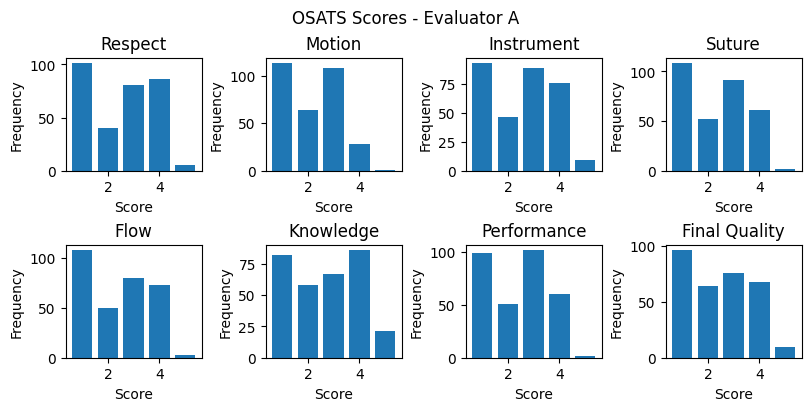

In [38]:
import matplotlib.pyplot as plt

names = ["Respect", "Motion", "Instrument", "Suture", "Flow", "Knowledge", "Performance", "Final Quality"]
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(8, 4), layout="constrained")
fig.suptitle("OSATS Scores - Evaluator A")

for x in range(2):
    for y in range(4):
        i = x * 4 + y
        categories = [1, 2, 3, 4, 5]
        values = count_all[i]
        axes[x, y].bar(categories, values)
        axes[x, y].set_title(names[i])
        axes[x, y].set_xlabel('Score')
        axes[x, y].set_ylabel('Frequency')
plt.show()

#### Lets combine everything together 

In [20]:
import csv
import matplotlib.pyplot as plt

def _read_based_on_evaluater(evaluater: str, file: str) -> list[list[str]]:
    """Return a list of list of score from a given
    evaluater ('A', 'B', 'C') and csv file."""
    raw_score = []
    with open(file, "r") as f:
        data = csv.reader(f)
        next(data)
        for row in data:
            if row[4] == evaluater:
                raw_score.append(row)
    return raw_score

def _score_distribution_per_osats(raw_score: list[list[str]]) -> list[list[int]]:
    """Return a list of all counts of score distribution per score."""
    count_all = [[0, 0, 0, 0, 0] for _ in range(0,8)]
    for i in range(0, 8):
        for item in raw_score:
            if item[6 + i] == '1':
                count_all[i][0] += 1
            elif item[6 + i] == '2':
                count_all[i][1] += 1
            elif item[6 + i] == '3':
                count_all[i][2] += 1
            elif item[6 + i] == '4':
                count_all[i][3] += 1
            else:
                count_all[i][4] += 1
    return count_all

def _plot_score_distribution(score_distribution: list[list[int]], title: str) -> None:
    """Print a firgure of 8 bar graphs for distribution for 8 OSTAS"""
    names = ["Respect", "Motion", "Instrument", "Suture",
             "Flow", "Knowledge", "Performance", "Final Quality"]
    fig, axes = plt.subplots(nrows=2, ncols=4,
                             figsize=(8, 4), layout="constrained")
    fig.suptitle(f"OSATS Score Distribution - Evaluator {title}")

    for x in range(2):
        for y in range(4):
            i = x * 4 + y
            categories = [1, 2, 3, 4, 5]
            values = score_distribution[i]
            axes[x, y].bar(categories, values)
            axes[x, y].set_title(names[i])
            axes[x, y].set_ylim(0, 150)
            axes[x, y].set_xlabel('Score')
            axes[x, y].set_ylabel('No of occurance')
    plt.show()

def score_distribution_per_evaluater(evaluater: str, file: str) -> None:
    """Read csv file, filter only an evaluater, then plot it"""
    raw_score = _read_based_on_evaluater(evaluater, file)
    print(raw_score)
    score_distribution = _score_distribution_per_osats(raw_score)
    print(score_distribution)
    _plot_score_distribution(score_distribution, evaluater)

[['AHO729', 'E-LEARNING', 'PRE', '1', 'A', 'P54M', '2', '1', '2', '2', '1', '2', '2', '1', '13'], ['AHO729', 'E-LEARNING', 'POST', '4.5', 'A', 'M45P', '4', '4', '4', '3', '3', '4', '3', '3', '28'], ['AHU348', 'TUTOR-LED', 'PRE', '0.5', 'A', 'D44W', '1', '1', '1', '1', '1', '1', '1', '1', '8'], ['AHU348', 'TUTOR-LED', 'POST', '3', 'A', 'W44D', '1', '1', '2', '1', '1', '2', '2', '1', '11'], ['AJJ164', 'E-LEARNING', 'PRE', '2.5', 'A', 'V34K', '1', '1', '1', '1', '1', '2', '1', '1', '9'], ['AJJ164', 'E-LEARNING', 'POST', '6', 'A', 'K43V', '3', '2', '3', '3', '2', '3', '2', '3', '21'], ['ALN135', 'E-LEARNING', 'PRE', '0.5', 'A', 'V16A', '1', '1', '1', '1', '1', '1', '1', '1', '8'], ['ALN135', 'E-LEARNING', 'POST', '3.5', 'A', 'A61V', '4', '2', '3', '3', '2', '3', '3', '4', '24'], ['ASG463', 'HMD-BASED', 'PRE', '0.5', 'A', 'S84F', '1', '1', '1', '1', '1', '1', '1', '1', '8'], ['ASG463', 'HMD-BASED', 'POST', '3', 'A', 'F48S', '2', '3', '3', '3', '4', '5', '3', '4', '27'], ['AVY994', 'TUTOR-LE

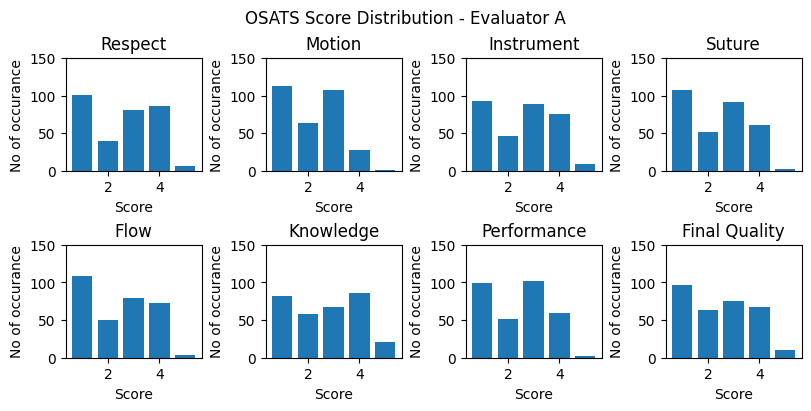

In [21]:
score_distribution_per_evaluater(evaluater='A', file="/home/sov1/OpenSutureNet/data/osats_score.csv")

[['AHO729', 'E-LEARNING', 'PRE', '1', 'B', 'P54M', '2', '1', '3', '1', '2', '1', '2', '1', '13'], ['AHO729', 'E-LEARNING', 'POST', '4.5', 'B', 'M45P', '2', '3', '4', '3', '3', '4', '3', '3', '25'], ['AHU348', 'TUTOR-LED', 'PRE', '0.5', 'B', 'D44W', '1', '1', '1', '1', '2', '1', '1', '1', '9'], ['AHU348', 'TUTOR-LED', 'POST', '3', 'B', 'W44D', '2', '2', '3', '3', '2', '3', '3', '2', '20'], ['AJJ164', 'E-LEARNING', 'PRE', '2.5', 'B', 'V34K', '3', '2', '3', '3', '2', '3', '2', '2', '20'], ['AJJ164', 'E-LEARNING', 'POST', '6', 'B', 'K43V', '4', '4', '4', '5', '4', '5', '5', '5', '36'], ['ALN135', 'E-LEARNING', 'PRE', '0.5', 'B', 'V16A', '4', '2', '3', '3', '2', '1', '2', '1', '18'], ['ALN135', 'E-LEARNING', 'POST', '3.5', 'B', 'A61V', '4', '3', '4', '3', '3', '4', '3', '4', '28'], ['ASG463', 'HMD-BASED', 'PRE', '0.5', 'B', 'S84F', '1', '2', '2', '1', '2', '1', '2', '1', '12'], ['ASG463', 'HMD-BASED', 'POST', '3', 'B', 'F48S', '1', '2', '3', '2', '2', '4', '3', '3', '20'], ['AVY994', 'TUTOR

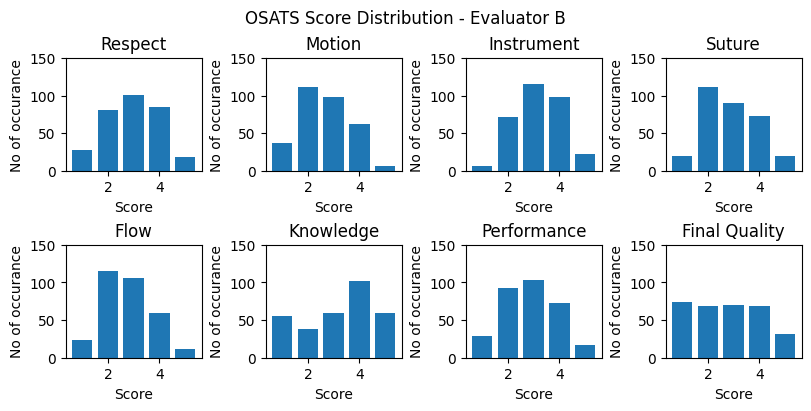

In [22]:
score_distribution_per_evaluater(evaluater='B', file="/home/sov1/OpenSutureNet/data/osats_score.csv")

[['AHO729', 'E-LEARNING', 'PRE', '1', 'C', 'P54M', '2', '1', '1', '1', '1', '1', '1', '1', '9'], ['AHO729', 'E-LEARNING', 'POST', '4.5', 'C', 'M45P', '3', '2', '2', '2', '2', '3', '2', '2', '18'], ['AHU348', 'TUTOR-LED', 'PRE', '0.5', 'C', 'D44W', '1', '1', '1', '1', '1', '1', '1', '1', '8'], ['AHU348', 'TUTOR-LED', 'POST', '3', 'C', 'W44D', '1', '1', '1', '1', '2', '2', '1', '1', '10'], ['AJJ164', 'E-LEARNING', 'PRE', '2.5', 'C', 'V34K', '2', '2', '1', '1', '1', '2', '1', '1', '11'], ['AJJ164', 'E-LEARNING', 'POST', '6', 'C', 'K43V', '3', '4', '4', '4', '4', '4', '4', '4', '31'], ['ALN135', 'E-LEARNING', 'PRE', '0.5', 'C', 'V16A', '1', '1', '1', '1', '1', '1', '1', '1', '8'], ['ALN135', 'E-LEARNING', 'POST', '3.5', 'C', 'A61V', '4', '3', '2', '3', '3', '3', '3', '3', '24'], ['ASG463', 'HMD-BASED', 'PRE', '0.5', 'C', 'S84F', '1', '4', '2', '1', '4', '1', '1', '1', '15'], ['ASG463', 'HMD-BASED', 'POST', '3', 'C', 'F48S', '2', '3', '2', '4', '3', '4', '3', '3', '24'], ['AVY994', 'TUTOR-L

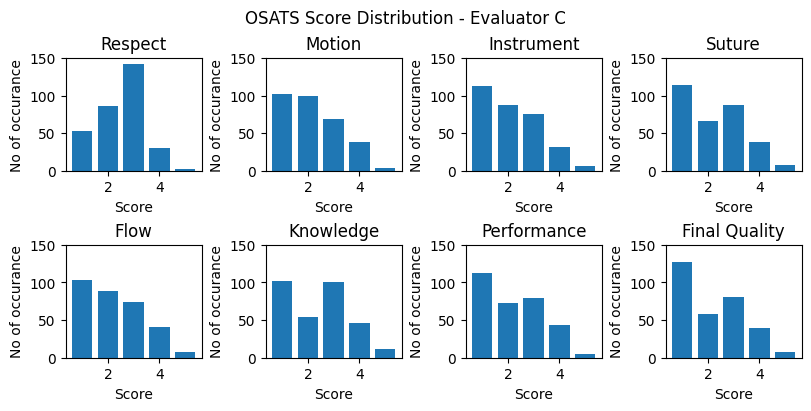

In [23]:
score_distribution_per_evaluater(evaluater='C', file="/home/sov1/OpenSutureNet/data/osats_score.csv")

## 2. PRE and POST Split

In [33]:
import numpy as np
from scipy import stats

def _read_pre(file: str) -> list[list[str]]:
    """Return a list of list of score from a given
    of only PRE tag"""
    raw_score = []
    with open(file, "r") as f:
        data = csv.reader(f)
        next(data)
        for row in data:
            if row[2] == 'PRE':
                raw_score.append(row)
    return raw_score

def _read_post(file: str) -> list[list[str]]:
    """Return a list of list of score from a given
    of only POST tag"""
    raw_score = []
    with open(file, "r") as f:
        data = csv.reader(f)
        next(data)
        for row in data:
            if row[2] == 'POST':
                raw_score.append(row)
    return raw_score

def _accumulate_grs(raw_score: list[list[str]]) -> list[int]:
    """Return a list of integers of grs form a raw_score"""
    accumulated_grs = []
    for item in raw_score:
        accumulated_grs.append(int(item[-1]))
    return accumulated_grs

def pre_post_stats_grs(file: str) -> dict:
    """Return a dictionary of mean grs"""
    output = {'PRE': {'mean': 0, 'median': 0},
                'POST': {'mean': 0, 'median': 0}}
    pre_raw_score = _read_pre(file)
    post_raw_score = _read_post(file)

    output['PRE']['mean'] = np.mean(_accumulate_grs(pre_raw_score))
    output['POST']['mean'] = np.mean(_accumulate_grs(post_raw_score))

    output['PRE']['median'] = np.median(_accumulate_grs(pre_raw_score))
    output['POST']['median'] = np.median(_accumulate_grs(post_raw_score))
    return output

In [34]:
pre_post_stats_grs("/home/sov1/OpenSutureNet/data/osats_score.csv")

{'PRE': {'mean': np.float64(14.097664543524417), 'median': np.float64(13.0)},
 'POST': {'mean': np.float64(26.537154989384288), 'median': np.float64(27.0)}}

## 3. Inter-rater Agreement
- what is an average agreement of 2 evaluaters: A, B, C
- calculate it robustly with Krippendorff's alpha 

Krippendorff's alpha :
- α = 1: Perfect reliability and agreement among all raters.
- α = 0: Agreement equals what is expected by random chance (no reliability).
- α < 0: Systematic disagreement, worse than random chance.

In [36]:
import csv
from nltk.metrics.agreement import AnnotationTask

def _read_grs_and_rater(file: str) -> list[list]:
    """Return a list of list of rater ('A', 'B', 'C')
    and grs score for each rater"""
    grs_and_rater_data = []
    with open(file, "r") as f:
        data = csv.reader(f)
        next(data)
        for item in data:
            grs_and_rater_data.append([item[4], int(item[-1])])
    return grs_and_rater_data

def calculate_krippendorff_alpha(file: str) -> float:
    grs_data = _read_grs_and_rater(file)
    # Initialize the annotation task
    task = AnnotationTask(grs_data)
    # Calculate Krippendorff's Alpha
    alpha_value = task.alpha()
    return alpha_value